# MIMIC basic usage

Fit MIMIC on a mixed tabular dataset, impute missing values, inspect confidence, and plot the original/preprocessed space against the learned embedding.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import MIMIC, RandomForestPathEncoder, MixedFeatureDecoder

rng = np.random.default_rng(0)
n = 120
age = rng.normal(50, 12, n)
income = 20000 + age * 850 + rng.normal(0, 5000, n)
segment = np.where(age > 50, "older", "younger")
outcome = np.where(income > np.median(income), "yes", "no")
df = pd.DataFrame({"id": range(n), "age": age, "income": income, "segment": segment, "outcome": outcome})
df.loc[rng.choice(n, 10, replace=False), "age"] = np.nan
df.loc[rng.choice(n, 8, replace=False), "outcome"] = np.nan
df.head()

,id,age,income,segment,outcome
0,0,51.508763,67720.389364,older,NaN
1,1,48.414742,65372.923797,younger,NaN
2,2,57.685072,69410.279088,older,yes
3,3,51.258801,56436.111940,older,no
4,4,43.571968,56360.946894,younger,no


In [2]:
mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["age", "income"],
    classification_columns=["segment", "outcome"],
    encoder=RandomForestPathEncoder(n_estimators=20, embedding_dim=8, random_state=0),
    decoder=MixedFeatureDecoder.random_forest(n_estimators=20, random_state=0),
    n_bootstrap=2,
    random_state=0,
)
mimic.fit(df)
embedding = mimic.transform(df)
embedding.shape

(120, 32)

In [3]:
imputed, confidence = mimic.impute(df, return_confidence=True)
imputed.head(), confidence.head()

(   id        age        income  segment outcome
 0   0  51.508763  67720.389364    older     yes
 1   1  48.414742  65372.923797  younger     yes
 2   2  57.685072  69410.279088    older     yes
 3   3  51.258801  56436.111940    older      no
 4   4  43.571968  56360.946894  younger      no,
    row_index column        task prediction   observed      bias   variance  \
 0          0    age  regression  55.658888  51.508763 -0.068479   6.704587   
 1          1    age  regression  48.135205  48.414742 -0.068479   0.021527   
 2          2    age  regression  59.044273  57.685072 -0.068479  10.850712   
 3          3    age  regression  51.330365  51.258801 -0.068479   0.000723   
 4          4    age  regression   45.07712  43.571968 -0.068479   0.350510   
 
    residual  uncertainty  discrepancy  ...  probability_std  probability_min  \
 0 -4.150126    44.526510     4.150126  ...              NaN              NaN   
 1  0.279537    37.843451     0.279537  ...              NaN       

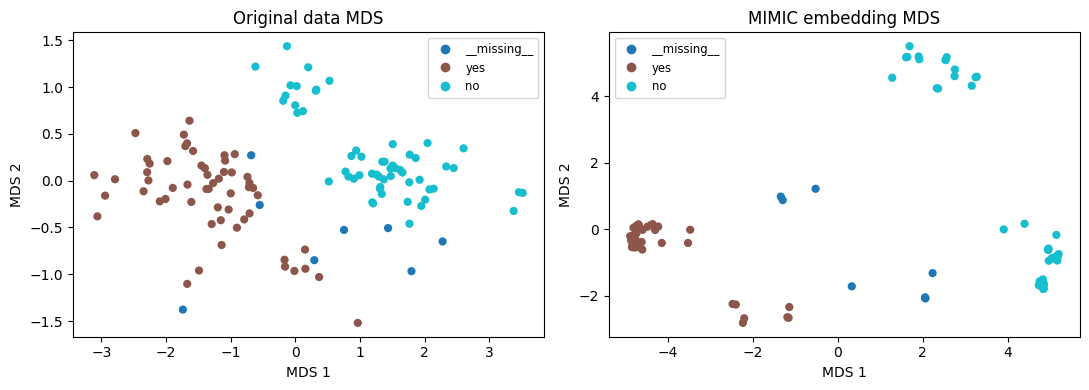

In [4]:
fig, axes = mimic.plot(df, color_by="outcome", center="random", random_state=0)